In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

# Read your CSV file
# Expected format: date, event, description (optional)
# Example CSV:
# date,event,description
# 2020-01-15,Project Start,Initial planning phase
# 2020-06-20,Milestone 1,First prototype completed

df = pd.read_csv('your_timeline.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ==== STYLE 1: Horizontal Timeline with Matplotlib ====
def plot_horizontal_timeline(df, figsize=(14, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the main timeline
    ax.plot(df['date'], [0]*len(df), 'o-', linewidth=2, markersize=10, color='#4CAF50')
    
    # Add event labels
    for i, (date, event) in enumerate(zip(df['date'], df['event'])):
        # Alternate labels above and below
        y_pos = 0.5 if i % 2 == 0 else -0.5
        va = 'bottom' if i % 2 == 0 else 'top'
        
        ax.text(date, y_pos, event, ha='center', va=va, fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#4CAF50'))
        ax.plot([date, date], [0, y_pos*0.8], 'k--', linewidth=0.5, alpha=0.5)
    
    # Formatting
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.title('Project Timeline', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==== STYLE 2: Vertical Timeline ====
def plot_vertical_timeline(df, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    
    y_positions = np.arange(len(df))
    
    # Plot vertical line
    ax.plot([0, 0], [0, len(df)-1], linewidth=3, color='#2196F3', zorder=1)
    
    # Plot events
    for i, (date, event, desc) in enumerate(zip(df['date'], df['event'], 
                                                  df.get('description', [''] * len(df)))):
        ax.scatter(0, i, s=200, color='#2196F3', zorder=2, edgecolors='white', linewidths=3)
        
        date_str = date.strftime('%Y-%m-%d')
        label = f"{date_str}\n{event}"
        if desc:
            label += f"\n{desc}"
        
        ax.text(0.5, i, label, ha='left', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#2196F3'))
    
    ax.set_xlim(-1, 3)
    ax.set_ylim(-0.5, len(df)-0.5)
    ax.axis('off')
    plt.title('Timeline', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# ==== STYLE 3: Gantt-style Timeline (good for durations) ====
def plot_gantt_timeline(df, figsize=(12, 8)):
    # Assumes CSV has: date, event, duration (in days)
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(df)))
    
    for i, (date, event, duration) in enumerate(zip(df['date'], df['event'], 
                                                      df.get('duration', [30] * len(df)))):
        ax.barh(i, duration, left=date, height=0.6, color=colors[i], 
                edgecolor='black', linewidth=1)
        ax.text(date, i, f"  {event}", va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.title('Project Gantt Timeline', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==== STYLE 4: Clean Matplotlib Timeline ====
def plot_clean_timeline(df, figsize=(14, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    
    dates = mdates.date2num(df['date'])
    
    # Main timeline
    ax.plot(dates, [1]*len(dates), 'o', markersize=12, color='#FF5722', zorder=3)
    ax.hlines(1, dates.min(), dates.max(), colors='#FF5722', linewidth=2)
    
    # Event labels
    for i, (date, event) in enumerate(zip(dates, df['event'])):
        y_offset = 1.2 if i % 2 == 0 else 0.8
        ax.annotate(event, xy=(date, 1), xytext=(date, y_offset),
                   ha='center', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#FF5722'),
                   arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    ax.set_ylim(0.5, 1.5)
    ax.set_yticks([])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.title('Timeline', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# ==== Run your preferred style ====
# Uncomment the one you want:

# plot_horizontal_timeline(df)
# plot_vertical_timeline(df)
# plot_gantt_timeline(df)  # Needs 'duration' column in CSV
# plot_clean_timeline(df)

print("Timeline functions loaded!")
print("\nYour CSV should have these columns:")
print("- date (format: YYYY-MM-DD)")
print("- event (short title)")
print("- description (optional)")
print("- duration (optional, for Gantt style)")
print("\nCall one of the functions:")
print("  plot_horizontal_timeline(df)")
print("  plot_vertical_timeline(df)")
print("  plot_gantt_timeline(df)")
print("  plot_clean_timeline(df)")

Timeline functions loaded!

Your CSV should have these columns:
- date (format: YYYY-MM-DD)
- event (short title)
- description (optional)
- duration (optional, for Gantt style)

Call one of the functions:
  plot_horizontal_timeline(df)
  plot_vertical_timeline(df)
  plot_gantt_timeline(df)
  plot_clean_timeline(df)


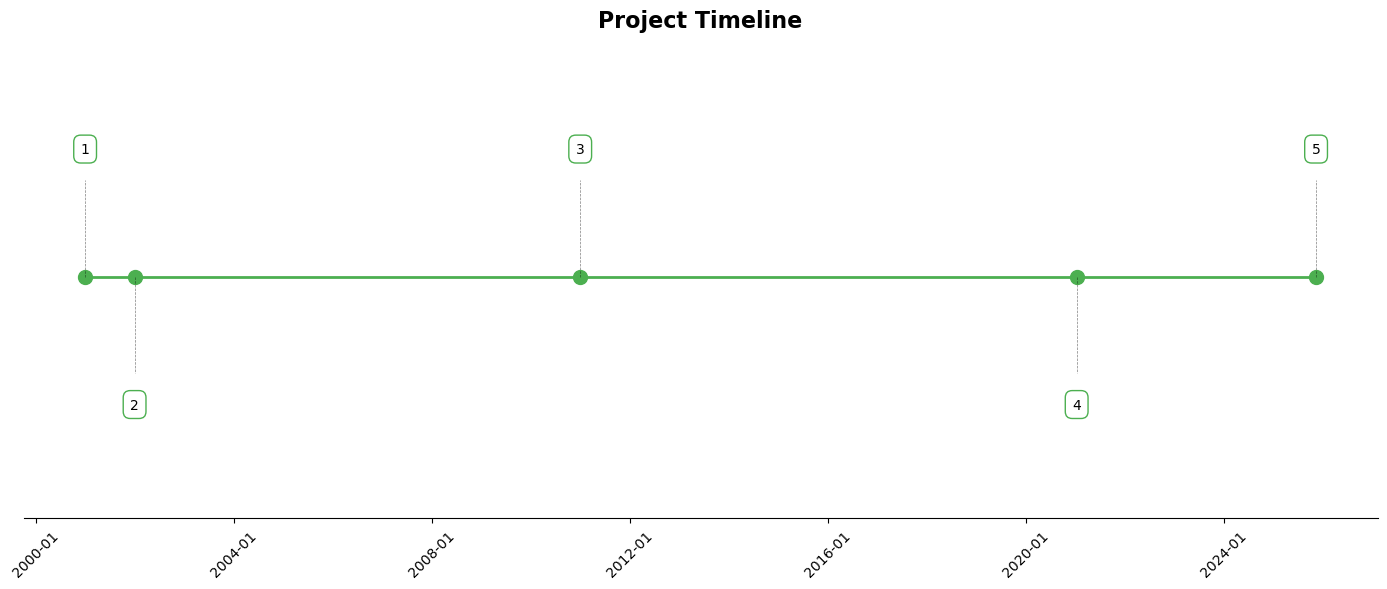

In [18]:
 plot_horizontal_timeline(df)

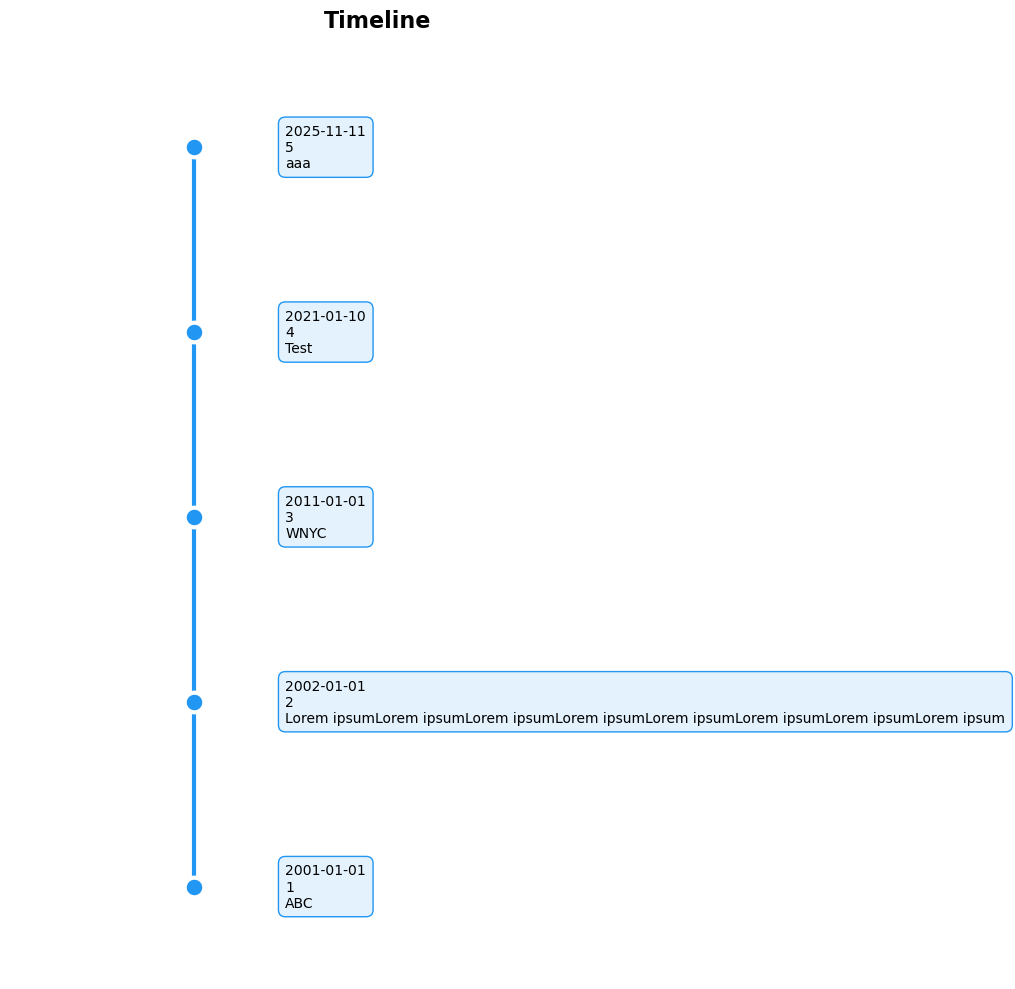

In [20]:
 plot_vertical_timeline(df)

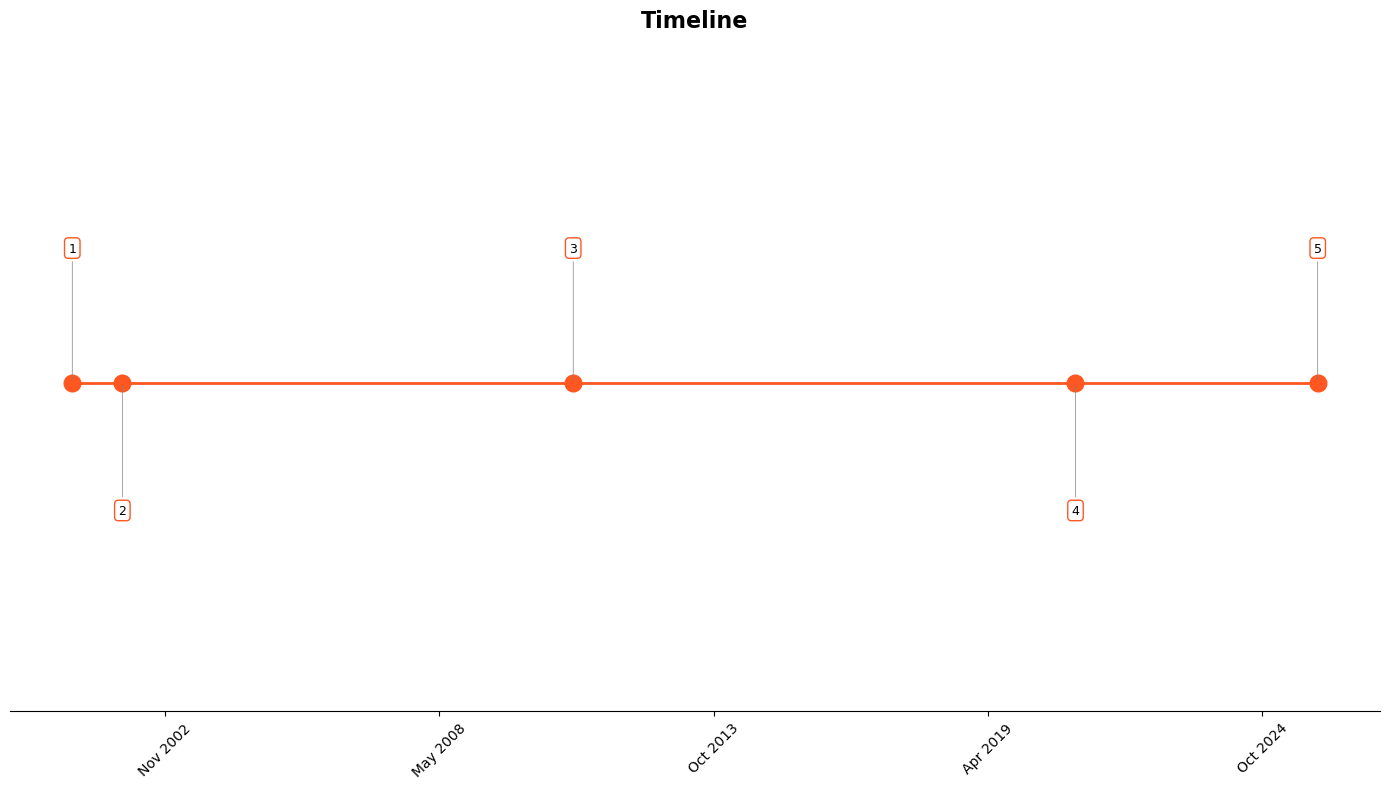

In [14]:
 plot_clean_timeline(df)